**ФИО:** Керимова Жанна Руслановна
**Группа:** ИУ5-61Б  
**Вариант:** 9  
**Задача:** №2 (Обработка пропусков)  

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
import warnings
warnings.filterwarnings('ignore')

In [5]:
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target_names[iris.target]

print("Датасет Iris загружен!")
print(f"Размер данных: {df.shape}")
print("\nПервые 5 строк:")
print(df.head())

Датасет Iris загружен!
Размер данных: (150, 5)

Первые 5 строк:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  


In [6]:
# СОЗДАНИЕ ПРОПУСКОВ (так как исходный датасет их не содержит)
np.random.seed(42)
df_missing = df.copy()

# Пропуски в количественном признаке
missing_len = np.random.choice(df_missing.index, size=10, replace=False)
df_missing.loc[missing_len, 'sepal length (cm)'] = np.nan

# Пропуски в категориальном признаке
missing_cat = np.random.choice(df_missing.index, size=10, replace=False)
df_missing.loc[missing_cat, 'species'] = np.nan

print(f"Пропусков в 'sepal length (cm)': {df_missing['sepal length (cm)'].isnull().sum()}")
print(f"Пропусков в 'species': {df_missing['species'].isnull().sum()}")


Пропусков в 'sepal length (cm)': 10
Пропусков в 'species': 10


In [7]:
# ОБРАБОТКА ПРОПУСКОВ: количественный признак (медиана)
print("Обработка количественного признака 'sepal length (cm)':")
print(f"Медиана до заполнения: {df_missing['sepal length (cm)'].median():.2f}")

median_val = df_missing['sepal length (cm)'].median()
df_missing['sepal length (cm)'].fillna(median_val, inplace=True)

print(f"Заполнено медианой: {median_val:.2f}")
print(f"Пропусков после: {df_missing['sepal length (cm)'].isnull().sum()}")

Обработка количественного признака 'sepal length (cm)':
Медиана до заполнения: 5.75
Заполнено медианой: 5.75
Пропусков после: 0


In [8]:
# ОБРАБОТКА ПРОПУСКОВ: категориальный признак (мода)
print("Обработка категориального признака 'species':")
mode_val = df_missing['species'].mode()[0]
print(f"Мода до заполнения: '{mode_val}'")

df_missing['species'].fillna(mode_val, inplace=True)

print(f"Заполнено модой: '{mode_val}'")
print(f"Пропусков после: {df_missing['species'].isnull().sum()}")


Обработка категориального признака 'species':
Мода до заполнения: 'versicolor'
Заполнено модой: 'versicolor'
Пропусков после: 0


In [9]:
# ПРОВЕРКА РЕЗУЛЬТАТА
print("Все пропуски обработаны:")
print(df_missing.isnull().sum())
print("\nПервые 10 строк результата:")
df_missing.head(10)

Все пропуски обработаны:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

Первые 10 строк результата:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,versicolor


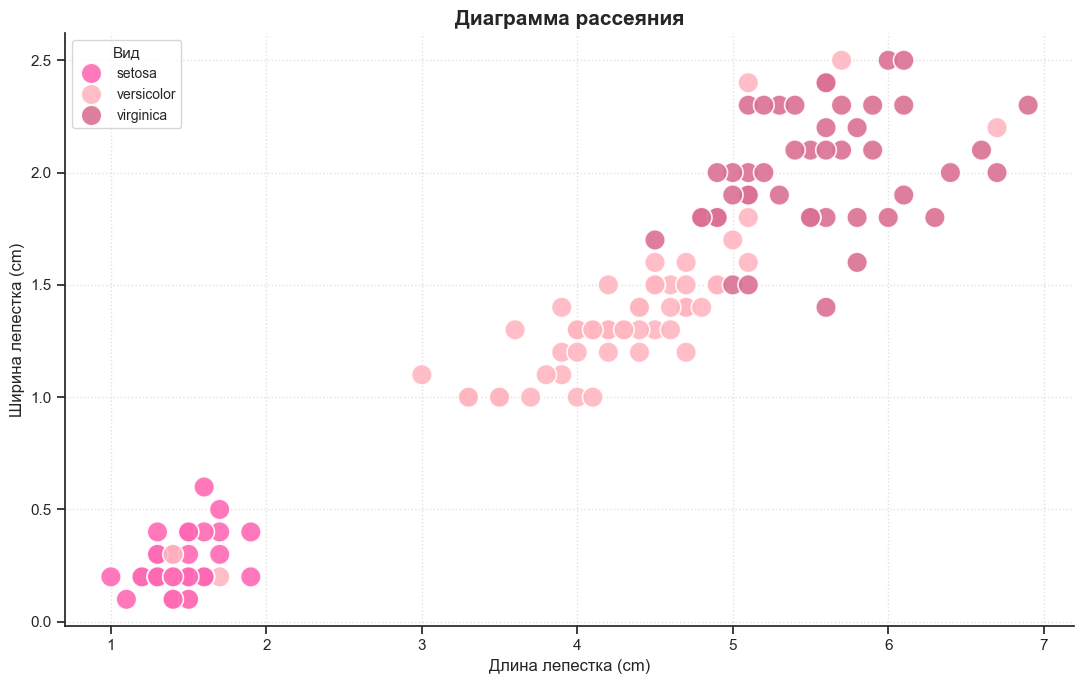

In [20]:
# ДИАГРАММА РАССЕЯНИЯ 
plt.figure(figsize=(11, 7))

sns.set_theme(style='ticks')
rose_colors = ['#FF69B4', '#FF85C1', '#FFA0D0', '#FFB6C1', '#FFC0CB', '#DB7093']

sns.scatterplot(
    data=df_missing,
    x='petal length (cm)',
    y='petal width (cm)',
    hue='species',
    style='species',
    s=220,
    palette=['#FF69B4', '#FFB6C1', '#DB7093'],  
    markers={'setosa': 'o', 'versicolor': 'o', 'virginica': 'o'},  

    linewidth=1.2,
    alpha=0.9
)

plt.title('Диаграмма рассеяния', fontsize=15, fontweight='bold')
plt.xlabel('Длина лепестка (cm)', fontsize=12)
plt.ylabel('Ширина лепестка (cm)', fontsize=12)
plt.legend(title='Вид', title_fontsize=11, fontsize=10, loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
sns.despine()  

plt.tight_layout()
plt.show()

**ВЫВОД ПО ДИАГРАММЕ РАССЕЯНИЯ:**
- Вид setosa хорошо отделим от других видов 
- Вид versicolor и virginica имеют пересекающиеся области
- Признаки длины и ширины лепестка информативны для классификации

1. ИСПОЛЬЗОВАННЫЕ МЕТОДЫ:
   - Количественный признак: ЗАПОЛНЕНИЕ МЕДИАНОЙ
   - Категориальный признак: ЗАПОЛНЕНИЕ МОДОЙ

2. ПОЧЕМУ ЭТИ МЕТОДЫ:
   - Медиана устойчива к выбросам
   - Мода — единственный вариант для категорий

3. ПРИЗНАКИ ДЛЯ МОДЕЛЕЙ МЛ:
   - Все 4 количественных признака
   - Целевой признак: species